##Data 1


In [ ]:
# ============================================================================
# WATER BODY SEGMENTATION - COMPLETE PIPELINE
# ============================================================================

# ============================================================================
# CELL 1: Setup - Check GPU and Install Libraries
# ============================================================================

import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

!pip install segmentation-models-pytorch -q


GPU available: True
Device: Tesla T4


In [ ]:

# ============================================================================
# CELL 2: Mount Google Drive
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/water_segmentation', exist_ok=True)
print("Drive mounted. Results saved to: /content/drive/MyDrive/water_segmentation/")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Results saved to: /content/drive/MyDrive/water_segmentation/


In [ ]:
# ============================================================================
# CELL 3: Setup Kaggle API
# ============================================================================

!pip install kaggle -q

from google.colab import files
import os

print("Upload your kaggle.json file:")
uploaded = files.upload()

# Find the uploaded kaggle.json file
kaggle_json_filename = None
if 'kaggle.json' in uploaded:
    kaggle_json_filename = 'kaggle.json'
elif uploaded: # If uploaded dictionary is not empty, take the first key
    kaggle_json_filename = list(uploaded.keys())[0]

if kaggle_json_filename:
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
        f.write(uploaded[kaggle_json_filename])
    os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
    print("Kaggle API configured!")
else:
    print("No kaggle.json file was uploaded. Please upload the file to proceed.")

Upload your kaggle.json file:


Saving kaggle.json to kaggle (3).json
Kaggle API configured!


In [ ]:
# ============================================================================
# CELL 4: Download and Extract Dataset
# ============================================================================

!kaggle datasets download -d franciscoescobar/satellite-images-of-water-bodies -p /content/
!unzip -q -o /content/satellite-images-of-water-bodies.zip -d /content/water_dataset
print("Dataset downloaded and extracted!")



Dataset URL: https://www.kaggle.com/datasets/franciscoescobar/satellite-images-of-water-bodies
License(s): CC-BY-NC-SA-4.0
100% 247M/247M [00:07<00:00, 36.3MB/s]

Dataset downloaded and extracted!


In [ ]:

# ============================================================================
# CELL 5: Import Libraries and Set Paths
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from tqdm import tqdm
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp

IMAGE_DIR = '/content/water_dataset/Water Bodies Dataset/Images'
MASK_DIR = '/content/water_dataset/Water Bodies Dataset/Masks'
SAVE_DIR = '/content/drive/MyDrive/water_segmentation'

print(f"Images found: {len(os.listdir(IMAGE_DIR))}")
print(f"Masks found: {len(os.listdir(MASK_DIR))}")


Images found: 2841
Masks found: 2841


##Data 2


In [ ]:
# ============================================================================
# CELL 1: Setup - Check GPU and Install Libraries
# ============================================================================

import torch
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

!pip install segmentation-models-pytorch -q



GPU available: True
Device: Tesla T4


In [ ]:

# ============================================================================
# CELL 2: Mount Google Drive
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/water_segmentation_humansintheloop', exist_ok=True)
print("Drive mounted. Results saved to: /content/drive/MyDrive/water_segmentation_humansintheloop/")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Results saved to: /content/drive/MyDrive/water_segmentation_humansintheloop/


In [ ]:

# ============================================================================
# CELL 3: Setup Kaggle API
# ============================================================================

!pip install kaggle -q

from google.colab import files
import os

print("Upload your kaggle.json file:")
uploaded = files.upload()

# Find the uploaded kaggle.json file
kaggle_json_filename = None
if 'kaggle.json' in uploaded:
    kaggle_json_filename = 'kaggle.json'
elif uploaded: # If uploaded dictionary is not empty, take the first key
    kaggle_json_filename = list(uploaded.keys())[0]

if kaggle_json_filename:
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
        f.write(uploaded[kaggle_json_filename])
    os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
    print("Kaggle API configured!")
else:
    print("No kaggle.json file was uploaded. Please upload the file to proceed.")


Upload your kaggle.json file:


Saving kaggle.json to kaggle (2).json
Kaggle API configured!


In [ ]:

# ============================================================================
# CELL 4: Download and Extract Dataset
# ============================================================================

# Check kaggle configuration
!kaggle datasets list -s water 2>&1 | head -5

# Download dataset
!kaggle datasets download -d humansintheloop/worlds-most-wanted-water-segmentation -p /content/ --force

# Check if file exists
!ls -lh /content/*.zip

# Unzip
!unzip -q /content/worlds-most-wanted-water-segmentation.zip -d /content/water_dataset_humansintheloop

# Verify extraction
!ls -R /content/water_dataset_humansintheloop | head -30

print("Dataset downloaded and extracted!")



ref                                                                   title                                             size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------------  ------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
adityakadiwal/water-potability                                        Water Quality                                   256729  2021-04-25 10:27:44.613000         124661       1683                1  
sudalairajkumar/chennai-water-management                              Chennai Water Management                         84391  2020-12-07 07:58:50.367000          15037        406                1  
mssmartypants/water-quality                                           Water quality                                   264223  2021-06-30 12:17:08.390000          18762        141        0.9117647  
403 Client

In [ ]:

# ============================================================================
# CELL 5: Import Libraries and Set Paths
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from tqdm import tqdm
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp

# Update paths for humansintheloop dataset structure
IMAGE_DIR = '/content/water_dataset_humansintheloop/images'
MASK_DIR = '/content/water_dataset_humansintheloop/masks'
SAVE_DIR = '/content/drive/MyDrive/water_segmentation_humansintheloop'

print(f"Images found: {len(os.listdir(IMAGE_DIR))}")
print(f"Masks found: {len(os.listdir(MASK_DIR))}")


##Code


In [ ]:
# ============================================================================
# CELL 6: 2a. Load Raw Data - Verify Count
# ============================================================================

image_files = sorted(os.listdir(IMAGE_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

print(f"Total image-mask pairs: {len(image_files)}")
print(f"Images: {len(image_files)}, Masks: {len(mask_files)}")
print(f"Counts match: {len(image_files) == len(mask_files)}")
print(f"Sample image: {image_files[6]}")
print(f"Sample mask: {mask_files[6]}")


Total image-mask pairs: 2841
Images: 2841, Masks: 2841
Counts match: True
Sample image: water_body_1004.jpg
Sample mask: water_body_1004.jpg


In [ ]:
# ============================================================================
# CELL 7: 2b. Mask Quality Check - Count Zero-Water Masks
# ============================================================================

zero_water_count = 0
total_masks = len(mask_files)

print("Checking mask quality...")
for mask_file in tqdm(mask_files):
    mask = Image.open(os.path.join(MASK_DIR, mask_file)).convert('L')
    mask_array = np.array(mask)
    if mask_array.max() == 0:
        zero_water_count += 1

print(f"\\nTotal masks: {total_masks}")
print(f"Fully black masks (no water): {zero_water_count}")
print(f"Percentage: {100 * zero_water_count / total_masks:.2f}%")


Checking mask quality...


100%|██████████| 2841/2841 [00:09<00:00, 290.86it/s]

\nTotal masks: 2841
Fully black masks (no water): 0
Percentage: 0.00%


Computing water ratios...


100%|██████████| 2841/2841 [00:12<00:00, 231.01it/s]


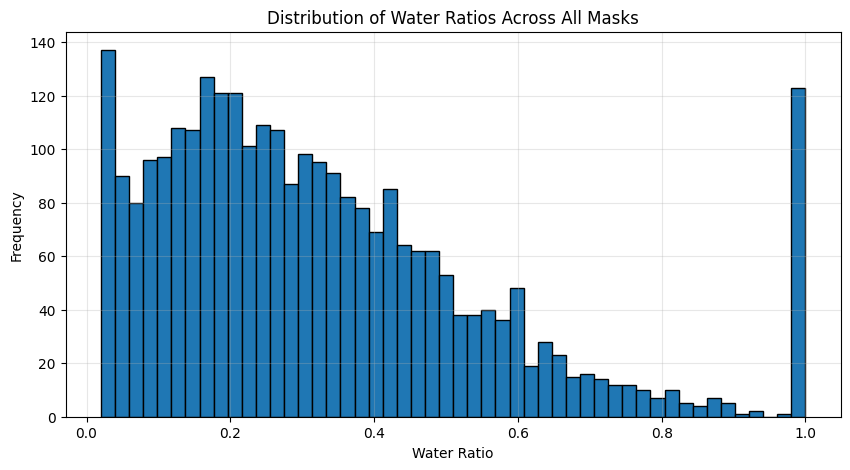


Mean water ratio: 0.3289
Min water ratio: 0.0200
Max water ratio: 1.0000


In [ ]:

# ============================================================================
# CELL 8: 2c. Class Imbalance Analysis
# ============================================================================

water_ratios = []

print("Computing water ratios...")
for mask_file in tqdm(mask_files):
    mask = Image.open(os.path.join(MASK_DIR, mask_file)).convert('L')
    mask_array = np.array(mask)
    white_pixels = (mask_array > 127).sum()
    total_pixels = mask_array.size
    water_ratio = white_pixels / total_pixels
    water_ratios.append(water_ratio)

water_ratios = np.array(water_ratios)

plt.figure(figsize=(10, 5))
plt.hist(water_ratios, bins=50, edgecolor='black')
plt.xlabel('Water Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Water Ratios Across All Masks')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nMean water ratio: {water_ratios.mean():.4f}")
print(f"Min water ratio: {water_ratios.min():.4f}")
print(f"Max water ratio: {water_ratios.max():.4f}")


In [ ]:
# ============================================================================
# CELL 9: 2d. Pixel Value Distribution
# ============================================================================
'''
sample_size = 200
sampled_images = random.sample(image_files, min(sample_size, len(image_files)))

r_values, g_values, b_values = [], [], []

print("Computing pixel value distributions...")
for img_file in tqdm(sampled_images):
    img = Image.open(os.path.join(IMAGE_DIR, img_file)).convert('RGB')
    img_array = np.array(img)
    r_values.extend(img_array[:, :, 0].flatten())
    g_values.extend(img_array[:, :, 1].flatten())
    b_values.extend(img_array[:, :, 2].flatten())

plt.figure(figsize=(12, 4))
plt.hist(r_values, bins=50, alpha=0.5, label='Red', color='red')
plt.hist(g_values, bins=50, alpha=0.5, label='Green', color='green')
plt.hist(b_values, bins=50, alpha=0.5, label='Blue', color='blue')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('RGB Pixel Value Distribution (Sample of 200 Images)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("ImageNet normalization is appropriate for this dataset")
'''



In [ ]:

# ============================================================================
# CELL 10: 3. Custom Dataset Class with Preprocessing
# ============================================================================

class WaterBodyDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=256, augment=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.augment = augment
        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        fname = self.images[idx]
        image = Image.open(os.path.join(self.image_dir, fname)).convert('RGB')
        mask = Image.open(os.path.join(self.mask_dir, fname)).convert('L')

        # Resize
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)

        # Augmentation
        if self.augment:
            image, mask = self._augment(image, mask)

        # Image to tensor and normalize
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

        # Mask to binary tensor [1, H, W]
        mask = np.array(mask, dtype=np.float32)
        mask = (mask > 127).astype(np.float32)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask

    def _augment(self, image, mask):
        if random.random() > 0.5:
            image, mask = TF.hflip(image), TF.hflip(mask)
        if random.random() > 0.5:
            image, mask = TF.vflip(image), TF.vflip(mask)
        angle = random.choice([0, 90, 180, 270])
        image, mask = TF.rotate(image, angle), TF.rotate(mask, angle)
        if random.random() > 0.5:
            image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
            image = TF.adjust_contrast(image, random.uniform(0.8, 1.2))
        return image, mask

print("Dataset class defined!")



In [ ]:

# ============================================================================
# CELL 11: Create Train/Val/Test Splits and DataLoaders
# ============================================================================

BATCH_SIZE = 8
IMG_SIZE = 256

full_ds = WaterBodyDataset(IMAGE_DIR, MASK_DIR, img_size=IMG_SIZE, augment=False)

n = len(full_ds)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

# Enable augmentation for training only
train_ds.dataset.augment = True

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")



In [ ]:

# ============================================================================
# CELL 12: Visualize Sample Batch
# ============================================================================

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

imgs, masks = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(4):
    img_disp = (imgs[i] * STD + MEAN).permute(1, 2, 0).clamp(0, 1).numpy()
    msk_disp = masks[i, 0].numpy()
    axes[0, i].imshow(img_disp)
    axes[0, i].set_title("Image")
    axes[0, i].axis("off")
    axes[1, i].imshow(msk_disp, cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"Water: {msk_disp.mean():.2%}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


In [ ]:

# ============================================================================
# CELL 13: 4. Define U-Net Model
# ============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")



In [ ]:


# ============================================================================
# CELL 14: 5. Define Loss Functions
# ============================================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        dice = (2.0 * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1 - dice

class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(BCEDiceLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss(smooth=smooth)

    def forward(self, logits, targets):
        return 0.5 * self.bce(logits, targets) + 0.5 * self.dice(logits, targets)

criterion = BCEDiceLoss(smooth=1.0)
print("Loss function: BCEDiceLoss (0.5 * BCE + 0.5 * Dice)")


In [ ]:

# ============================================================================
# CELL 15: 6. Define Metrics
# ============================================================================

def iou_score(logits, targets, threshold=0.5, epsilon=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = targets.float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - intersection
    iou = (intersection + epsilon) / (union + epsilon)
    return iou.mean().item()

def dice_score(logits, targets, threshold=0.5, epsilon=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = targets.float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + epsilon) / (preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) + epsilon)
    return dice.mean().item()

print("Metrics defined: IoU and Dice")



In [ ]:

# ============================================================================
# CELL 16: 7. Training Setup
# ============================================================================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

EPOCHS = 30
best_val_loss = float('inf')

history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_dice': []
}

print("Training setup complete!")
print(f"Optimizer: Adam (lr=1e-4)")
print(f"Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)")
print(f"Epochs: {EPOCHS}")



In [ ]:

# ============================================================================
# CELL 17: Training Loop
# ============================================================================
for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_iou += iou_score(outputs, masks)
            val_dice += dice_score(outputs, masks)

    val_loss /= len(val_loader)
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    # Update scheduler
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f} | Val Dice: {val_dice:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, 'best_model.pth'))
        print(f"  → Best model saved! (Val Loss: {val_loss:.4f})")

print("\\nTraining complete!")



In [ ]:

# ============================================================================
# CELL 18: 8. Evaluation on Test Set
# ============================================================================

# Load best model
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, 'best_model.pth')))
model.eval()

test_iou = 0.0
test_dice = 0.0

print("Evaluating on test set...")
with torch.no_grad():
    for images, masks in tqdm(test_loader):
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)

        test_iou += iou_score(outputs, masks)
        test_dice += dice_score(outputs, masks)

test_iou /= len(test_loader)
test_dice /= len(test_loader)

print(f"\\nTest Results:")
print(f"Test IoU: {test_iou:.4f}")
print(f"Test Dice: {test_dice:.4f}")



In [ ]:

# ============================================================================
# CELL 19: 9. Visualization - Training Curves
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train Loss
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val Loss
axes[1].plot(history['val_loss'], label='Val Loss', marker='o', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Val IoU
axes[2].plot(history['val_iou'], label='Val IoU', marker='o', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('IoU')
axes[2].set_title('Validation IoU')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved!")


In [ ]:
# ============================================================================
# CELL 20: 9. Visualization - Predictions Grid
# ============================================================================

# Get 6 random test samples
test_samples = []
test_indices = random.sample(range(len(test_ds)), 6)

model.eval()
with torch.no_grad():
    for idx in test_indices:
        image, mask = test_ds[idx]
        image_input = image.unsqueeze(0).to(device)
        output = model(image_input)
        pred = torch.sigmoid(output).squeeze().cpu().numpy()

        # Denormalize image for display
        img_disp = (image * STD + MEAN).permute(1, 2, 0).clamp(0, 1).numpy()
        mask_disp = mask.squeeze().numpy()

        # Calculate IoU for this sample
        pred_binary = (pred > 0.5).astype(np.float32)
        intersection = (pred_binary * mask_disp).sum()
        union = pred_binary.sum() + mask_disp.sum() - intersection
        sample_iou = intersection / (union + 1e-6)

        test_samples.append((img_disp, mask_disp, pred, sample_iou))

# Plot 6x3 grid
fig, axes = plt.subplots(6, 3, figsize=(12, 24))

for i, (img, mask, pred, iou) in enumerate(test_samples):
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask, cmap="gray", vmin=0, vmax=1)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred, cmap="gray", vmin=0, vmax=1)
    axes[i, 2].set_title(f"Prediction (IoU: {iou:.3f})")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'segmentation_results.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Segmentation results saved!")



In [ ]:

# ============================================================================
# CELL 21: Summary
# ============================================================================
print("\\n" + "="*60)
print("WATER BODY SEGMENTATION - SUMMARY")
print("="*60)
print(f"Dataset: 2841 image-mask pairs")
print(f"Train/Val/Test Split: {len(train_ds)}/{len(val_ds)}/{len(test_ds)}")
print(f"Model: U-Net with ResNet50 encoder")
print(f"Loss: BCEDiceLoss (0.5 * BCE + 0.5 * Dice)")
print(f"\\nBest Validation Loss: {best_val_loss:.4f}")
print(f"Test IoU: {test_iou:.4f}")
print(f"Test Dice: {test_dice:.4f}")
print(f"\\nResults saved to: {SAVE_DIR}")
print("="*60)

